In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import SimpleRNN,Dense

In [40]:
df=pd.read_csv('./Datasets/google.csv')

data=pd.to_numeric(df['Open'],errors='coerce').dropna().values.reshape(-1,1)

df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [41]:
scaler=MinMaxScaler(feature_range=(0,1))

data_scaled=scaler.fit_transform(data)

In [42]:
train_size=int(len(data_scaled)*0.8)

train_data=data_scaled[:train_size]

test_data=data_scaled[train_size:]

In [43]:
def create_dataset(dataset,time_step=5):
    X=[]
    y=[]

    for i in range(time_step,len(dataset)):
        X.append(dataset[i-time_step:i,0])
        y.append(dataset[i,0])
    return np.array(X),np.array(y)

In [44]:
time_step=5

x_train,y_train=create_dataset(train_data,time_step)

x_test,y_test=create_dataset(test_data,time_step)

In [45]:
x_train=x_train.reshape(x_train.shape[0],x_train.shape[1],1)
x_test=x_test.reshape(x_test.shape[0],x_test.shape[1],1)

In [46]:
model=Sequential()

model.add(SimpleRNN(50,return_sequences=True,input_shape=(time_step,1)))
model.add(SimpleRNN(50))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

model.summary()

C:\Users\kunal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)             │ (None, 5, 50)               │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0518
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0574
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0353
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0433
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0178
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0371
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0209
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0182
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0201
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0124
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0143
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0141
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0109
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0106
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0096
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━

In [48]:
predictions=model.predict(x_test)
real=scaler.inverse_transform(y_test.reshape(-1,1))
predictions=scaler.inverse_transform(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


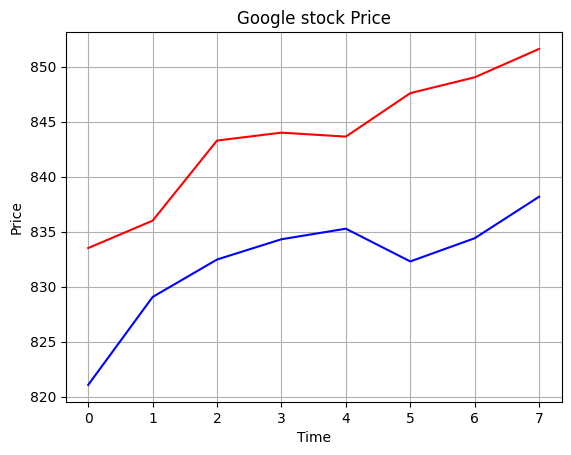

In [49]:
plt.plot(real,color='red')
plt.plot(predictions,color='blue')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Google stock Price')
plt.grid(True)
plt.show()